In [ ]:
import pickle
from pathlib import Path

from src.common.artifacts import IntermediateArtifacts

p = Path(r"C:/Users/sueya/Git-Repositories/takano_labo/dca/output/artifacts/intermediate/dataset_fashion_mnist_F_type_umap_gamma_ratio_1_data_distribution_bias_dim_intermediate_15_num_institution_us_deb8a11b70.pkl")

with p.open("rb") as f:
    inter_art: IntermediateArtifacts = pickle.load(f)

print(type(inter_art))
print("anchor:", inter_art.anchor.shape)
print("anchor_y:", inter_art.anchor_y.shape)
print("graph_adjacency is None?", inter_art.graph_adjacency is None)


<class 'src.common.artifacts.IntermediateArtifacts'>
anchor: (1000, 784)
anchor_y: (1000,)
graph_adjacency is None? True


In [11]:
import numpy as np
from src.intermediate_expression.anchor_utils import build_laplacians_from_intermediate_data

# グラフ用のパラメータ（必要に応じて調整）
graph_k = 10
metric = "euclidean"
normalize = True

adjacency, graph_Lw, graph_Lb = build_laplacians_from_intermediate_data(
    Xs_inter=inter_art.Xs_train_inter,
    anchors_inter=inter_art.anchors_inter,
    ys=inter_art.dataset.ys_train,
    k_neighbors=graph_k,
    metric=metric,
    normalize=normalize,
    logger=None,
)

anchor = inter_art.anchor
anchor_y = inter_art.anchor_y
A = adjacency

print("adjacency shape:", A.shape)


adjacency shape: (1500, 1500)


In [12]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import SpectralEmbedding

A_bin = (A > 0).astype(int)
n = A_bin.shape[0]
labels = anchor_y

# 連結成分
G = nx.from_numpy_array(A_bin)
n_comp = nx.number_connected_components(G)
comp_sizes = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
print("connected components:", n_comp)
print("largest component sizes:", comp_sizes[:5])

# 近傍の同一ラベル割合
same_frac = []
for i in range(n):
    neighbors = np.where(A_bin[i] > 0)[0]
    if neighbors.size == 0:
        continue
    same = np.sum(labels[neighbors] == labels[i])
    same_frac.append(same / neighbors.size)
same_frac = np.array(same_frac)
print("mean same-label neighbor ratio:", float(same_frac.mean()))
print("median same-label neighbor ratio:", float(np.median(same_frac)))

# 2次元可視化
emb = SpectralEmbedding(n_components=2, affinity="precomputed").fit_transform(A)
plt.figure(figsize=(5,5))
sc = plt.scatter(emb[:,0], emb[:,1], c=labels, s=8, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="anchor label")
plt.title("Anchor graph (from saved IntermediateArtifacts)")
plt.show()


connected components: 1
largest component sizes: [1500]


IndexError: index 1005 is out of bounds for axis 0 with size 1000

(1000, 784) (1000,)
A_anchor shape: (1000, 1000)
connected components: 1
largest component sizes: [1000]
mean same-label neighbor ratio: 0.9690827594790831
median same-label neighbor ratio: 1.0


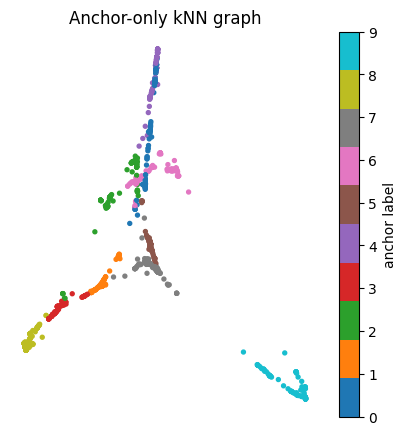

In [13]:
from src.intermediate_expression.anchor_utils import _symmetric_knn_graph
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import SpectralEmbedding

# 1. アンカーとラベルを取り出す
anchor = inter_art.anchor      # (N_anchor, d)
labels = inter_art.anchor_y    # (N_anchor,)

print(anchor.shape, labels.shape)

# 2. アンカー専用の k-NN グラフを作る（特徴空間はお好みで）
k = 10  # 近傍数
A_anchor = _symmetric_knn_graph(anchor, k_neighbors=k, metric="euclidean")
A_bin = (A_anchor > 0).astype(int)

print("A_anchor shape:", A_anchor.shape)

# 3. 連結成分・同一ラベル近傍率などを見る
G = nx.from_numpy_array(A_bin)
n_comp = nx.number_connected_components(G)
comp_sizes = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
print("connected components:", n_comp)
print("largest component sizes:", comp_sizes[:5])

same_frac = []
for i in range(A_bin.shape[0]):
    neighbors = np.where(A_bin[i] > 0)[0]
    if neighbors.size == 0:
        continue
    same = np.sum(labels[neighbors] == labels[i])
    same_frac.append(same / neighbors.size)
same_frac = np.array(same_frac)
print("mean same-label neighbor ratio:", float(same_frac.mean()))
print("median same-label neighbor ratio:", float(np.median(same_frac)))

# 4. 2次元に落として可視化
emb = SpectralEmbedding(n_components=2, affinity="precomputed").fit_transform(A_anchor)
plt.figure(figsize=(5, 5))
sc = plt.scatter(emb[:, 0], emb[:, 1], c=labels, s=8, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="anchor label")
plt.title("Anchor-only kNN graph")
plt.show()


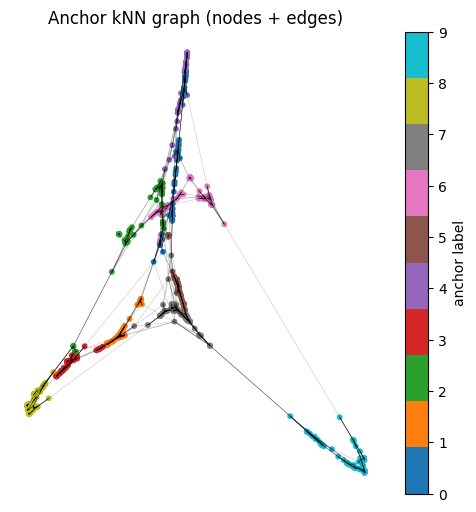

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import SpectralEmbedding

# A_anchor: アンカー用 kNN 隣接行列 (N×N)
# labels:   anchor_y (長さ N)

A_bin = (A_anchor > 0).astype(int)
G = nx.from_numpy_array(A_bin)

# 2次元埋め込み（さっきと同じ）
emb = SpectralEmbedding(n_components=2, affinity="precomputed").fit_transform(A_anchor)

plt.figure(figsize=(6, 6))

# 1. エッジを描画（多いので alpha を小さく）
i_idx, j_idx = np.where(np.triu(A_bin, k=1))
for i, j in zip(i_idx, j_idx):
    plt.plot(
        [emb[i, 0], emb[j, 0]],
        [emb[i, 1], emb[j, 1]],
        color="k",
        alpha=0.3,
        linewidth=0.3,
    )

# 2. ノード（アンカー）をラベル色で重ねる
sc = plt.scatter(emb[:, 0], emb[:, 1], c=labels, s=10, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="anchor label")
plt.title("Anchor kNN graph (nodes + edges)")
plt.show()


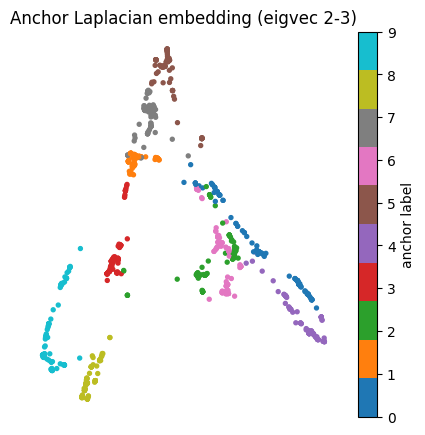

In [17]:
from sklearn.manifold import SpectralEmbedding

emb_full = SpectralEmbedding(
    n_components=4, affinity="precomputed"
).fit_transform(A_anchor)

# 2,3 成分で描く（0,1 ではなく）
emb = emb_full[:, 1:3]

plt.figure(figsize=(5,5))
sc = plt.scatter(emb[:,0], emb[:,1], c=inter_art.anchor_y, s=8, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="anchor label")
plt.title("Anchor Laplacian embedding (eigvec 2-3)")
plt.show()


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


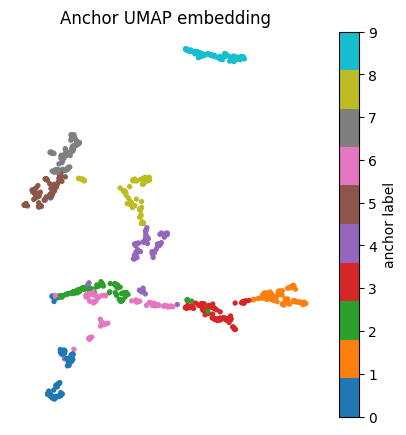

In [18]:
import umap
import matplotlib.pyplot as plt

# anchor_inter でも anchor でも OK（お好み）
X = inter_art.anchor  # or inter_art.anchors_inter[0] など

um = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0)
emb = um.fit_transform(X)

plt.figure(figsize=(5,5))
sc = plt.scatter(emb[:,0], emb[:,1], c=inter_art.anchor_y, s=8, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="anchor label")
plt.title("Anchor UMAP embedding")
plt.show()

A shape: (1000, 1000)


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


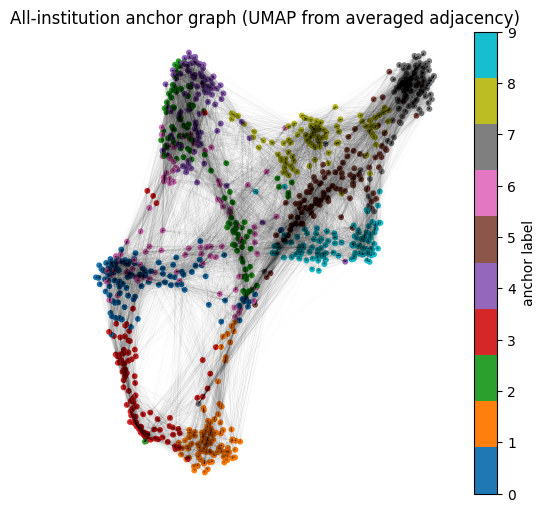

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from src.intermediate_expression.anchor_utils import _symmetric_knn_graph

anchors_list = inter_art.anchors_inter     # 各機関のアンカー (r, dim_inter)
labels = inter_art.anchor_y                # アンカーラベル (r,)

r = anchors_list[0].shape[0]
k = 10  # kNN の k

# 1. 機関ごとの kNN グラフを平均
W_sum = np.zeros((r, r), dtype=float)
for S in anchors_list:
    W_k = _symmetric_knn_graph(S, k_neighbors=k, metric="euclidean")
    W_sum += W_k

W_avg = W_sum / len(anchors_list)

# 2. 平均隣接行列を 0/1 にクリップ
A = (W_avg > 0).astype(float)   # or (W_avg > threshold)

print("A shape:", A.shape)

# 3. A から距離行列を作って UMAP 埋め込み
#    ここでは「隣接していれば距離0.0、そうでなければ1.0」の単純な距離にする
D = 1.0 - A
np.fill_diagonal(D, 0.0)

um = umap.UMAP(metric="precomputed", n_neighbors=15, min_dist=0.1, random_state=0)
emb = um.fit_transform(D)   # (r, 2)

# 4. エッジ込みで可視化
plt.figure(figsize=(6, 6))

# エッジを描画
i_idx, j_idx = np.where(np.triu(A, k=1) > 0)
for i, j in zip(i_idx, j_idx):
    plt.plot(
        [emb[i, 0], emb[j, 0]],
        [emb[i, 1], emb[j, 1]],
        color="k",
        alpha=0.1,
        linewidth=0.1,
    )

# ノード（アンカー）をラベルで色付け
sc = plt.scatter(emb[:, 0], emb[:, 1], c=labels, s=10, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="anchor label")
plt.title("All-institution anchor graph (UMAP from averaged adjacency)")
plt.show()


10D embedding shape: (1000, 20)


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


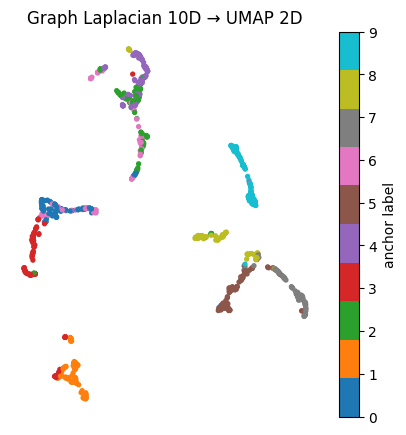

In [24]:
import numpy as np
from sklearn.manifold import SpectralEmbedding
import umap
import matplotlib.pyplot as plt

# A: アンカー間の隣接行列 (r×r, 対称, 非負)
# labels: anchor_y (長さ r)

# 1. グラフラプラシアンから 10 次元埋め込み（Laplacian Eigenmaps）
#    → ここでは scikit-learn の SpectralEmbedding を使う
embed10 = SpectralEmbedding(
    n_components=20,
    affinity="precomputed",
).fit_transform(A)          # shape: (r, 10)

print("10D embedding shape:", embed10.shape)

# 2. その 10 次元埋め込みを UMAP で 2 次元に
um = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=0,
)
emb2 = um.fit_transform(embed10)   # shape: (r, 2)

# 3. 可視化
plt.figure(figsize=(5, 5))
sc = plt.scatter(emb2[:, 0], emb2[:, 1], c=labels, s=8, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="anchor label")
plt.title("Graph Laplacian 10D → UMAP 2D")
plt.show()


c:\Users\sueya\Git-Repositories\takano_labo\dca\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


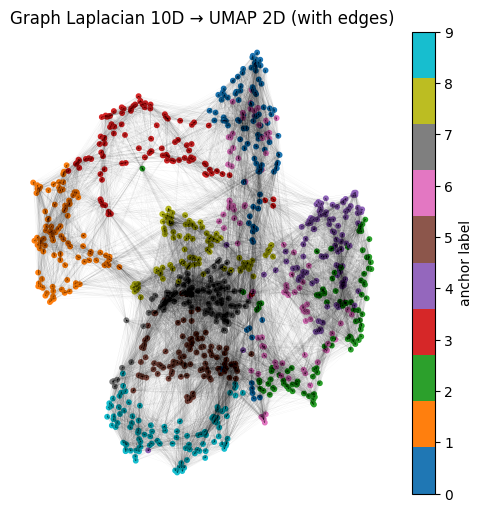

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import SpectralEmbedding
import umap

# A: アンカー間の隣接行列 (r×r, 対称, 非負)
# labels: anchor_y (長さ r)

# 1. グラフラプラシアン由来の 10次元埋め込み
embed10 = SpectralEmbedding(
    n_components=60,
    affinity="precomputed",
).fit_transform(A)          # shape: (r, 10)

um = umap.UMAP(
    n_neighbors=50,   # 30〜60 くらいを試すと良い
    min_dist=0.3,     # 0.3〜0.6 くらいで「密クラスター」を緩める
    metric="euclidean",
    random_state=0,
)
emb2 = um.fit_transform(embed10)   # shape: (r, 2)

# 3. エッジ付きで可視化
A_bin = (A > 0).astype(int)
i_idx, j_idx = np.where(np.triu(A_bin, k=1) > 0)

plt.figure(figsize=(6, 6))

# エッジ（線）
for i, j in zip(i_idx, j_idx):
    plt.plot(
        [emb2[i, 0], emb2[j, 0]],
        [emb2[i, 1], emb2[j, 1]],
        color="k",
        alpha=0.1,   # エッジが多いのでかなり薄く
        linewidth=0.1,
    )

# ノード（アンカー）
sc = plt.scatter(emb2[:, 0], emb2[:, 1], c=labels, s=10, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="anchor label")
plt.title("Graph Laplacian 10D → UMAP 2D (with edges)")
plt.show()


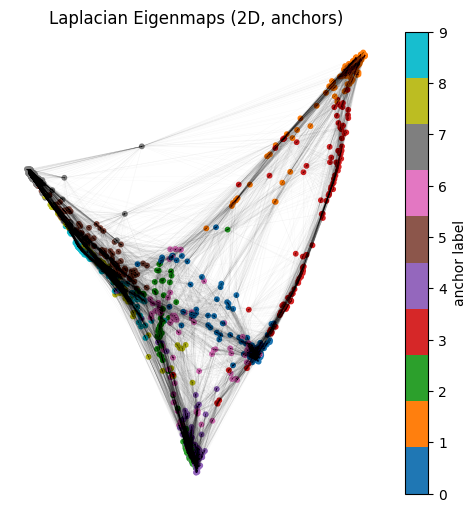

In [29]:
from sklearn.manifold import SpectralEmbedding
import matplotlib.pyplot as plt
import numpy as np

# A: アンカーグラフ隣接行列 (r×r), labels: anchor_y
A_bin = (A > 0).astype(int)

# 1. LE で直接 2 次元へ
emb2 = SpectralEmbedding(
    n_components=2,
    affinity="precomputed",
).fit_transform(A_bin)

# 2. エッジ付き可視化
i_idx, j_idx = np.where(np.triu(A_bin, k=1) > 0)

plt.figure(figsize=(6, 6))
for i, j in zip(i_idx, j_idx):
    plt.plot(
        [emb2[i, 0], emb2[j, 0]],
        [emb2[i, 1], emb2[j, 1]],
        color="k",
        alpha=0.03,
        linewidth=0.3,
    )

sc = plt.scatter(emb2[:, 0], emb2[:, 1], c=labels, s=10, cmap="tab10")
plt.axis("off")
plt.colorbar(sc, label="anchor label")
plt.title("Laplacian Eigenmaps (2D, anchors)")
plt.show()
